# Classificació MNIST multiclasse

El conjunt de dades MNIST (Modified National Institute of Standards and Technology) Digits és un dels datasets més populars en el món de l'aprenentatge automàtic. És una col·lecció de 70.000 imatges, de 28x28 en escala de grisos, de dígits escrits a mà i s'utilitza comunament per a entrenar models de reconeixement d'imatges i com un punt de referència per a nous algorismes. En el nostre cas l'usarem per a comprovar com entrenar models que estem veient i avaluar-los.

Però, les imatges són de dues dimensions i estem treballant amb dades tabulades en columnes (cada columna corresponent a cada variable independent seria una dimensió). Com convertim l'una en l'altra? És molt fàcil, i de passada ens demostra la potència d'aquests algorismes que són agnòstics respecte a informació o coneixement, només veuen números.

In [2]:

import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=True)


## Preparació de les dades

In [3]:
# El dataset és de tipus Bunch, que és un diccionari amb atributs accessibles com a propietats.
print(type(mnist))
# El resultat de fetch_openml és un diccionari amb les següents claus:
print(mnist.keys())
# Data conté les imatges en format vectorial (cada imatge és un vector de 784 dimensions)
print(mnist.data.shape)
# Target conté les etiquetes (els dígits)
print(mnist.target.shape)
# Frame conté les dades en format de DataFrame de pandas, conté les imatges i les etiquetes
print(mnist.frame.shape)
mnist.frame.head()

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)
(70000, 785)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [4]:
# Ens asegurem que les etiquetes són de tipus enter i no hi ha valors nuls o extrems
mnist.target = mnist.target.astype(np.int8)
np.unique(mnist.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int8)

In [5]:
X, y = mnist["data"], mnist["target"]
type(X), type(y)

(pandas.DataFrame, pandas.Series)

Ja tenim el dataset. Com que són imatges, les podem representar per veure cóm són. Això no és un pas imprescindible a l'entrenament del model, però fer una mínima exploració de les dades és important en la documentació del procés. També verifiquem que les dades són correctes. 

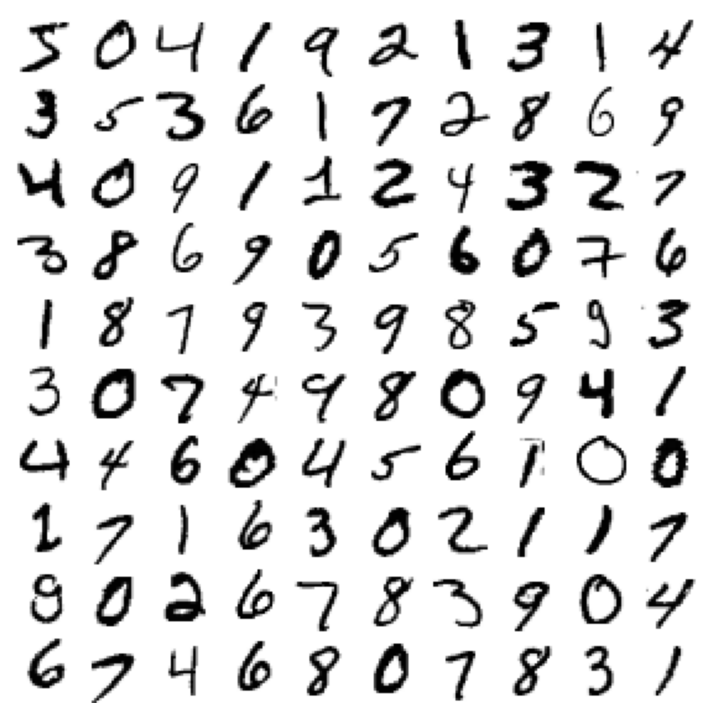

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)

    n_rows = (len(instances) - 1) // images_per_row + 1
    # otra forma de indicar el número de filas seria:
    # n_rows = ceil(len(instances) / images_per_row)   *ceil* proporciona el número entero del cociente
    
    # Añadimos imagenes vacias para completar la cuadrícula
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # En el caso de encontra imágenes de diferente tamaño al establecido, esto orden las reajusta a ese tamaño
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Se combinan los ejes 0 y 2 (verticales) con 1 y 3 (horizontales)
    # primero se colocan uno al lado del otro y se trasponen
    # reajustamos el tamaño de la imagen y obtenemos la caracterisitca de esa observaciñon
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    
    # Tras realizar la transformación como deseamos de la imagen ya podemos mostrarla
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

plt.figure(figsize=(9,9))
example_images = X[:100] 


plot_digits(example_images, images_per_row=10) 
plt.show()


## Entrenament amb un classificador binari

En el primer exemple veurem cóm detectar el número 5 front a tots els demés. És a dir, serà positiu si és un 5 i negatiu si és un altre número.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fem una operació booleana amb el conjunt d'etiquetes per crear un conjunt de dades binari on només ens interessen els dígits 5.
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)    # True for all 5s, False for all other digits

Ens interessa explorar un classificador amb hiperparàmetres que siga ràpid i amb descens de gradient. 

Els hiperparàmetres són:
* max_iter: El total màxim d'iteracions.
* tol: Criteri de parada, si arriba a aquest error es considera suficientment bó i para. 


In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

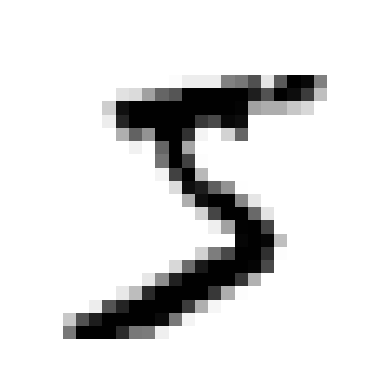

[False] 5


In [10]:


some_digit_image = X.iloc[0].to_numpy().reshape(28, 28) 
plt.imshow(some_digit_image, cmap=mpl.cm.binary) #indicamos que sea el color binary mpl.cm.gray
plt.axis("off")
plt.show()

print(sgd_clf.predict(X.iloc[[0]]), y.iloc[0])

### Mesures de rendiment

En els pasos anteriors hem fet un entrenament simple amb dades separades. Si volem saber si va a funcionar correctament amb totes les dades hem fer fer un Cross Validation. 

Finalment ja podriem entrenar amb totes les dades per posar el model en producció.

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Creem un model NOU i no entrenat (buit) de SGDClassifier
sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# 2. Definim l'estratègia
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Li passem el model "buit" a la cross_val_score
scores = cross_val_score(sgd_clf, X, y, cv=skf, scoring='accuracy')

print("Puntuacions de cada plec:", scores)
print("Precisió mitjana:", scores.mean())

KeyboardInterrupt: 

### Entrenament classificador binari Un contra tots

## Entrenament amb classificadors múltiples